In [2]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings('ignore', category=ConvergenceWarning)

import pandas as pd

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

import optuna

import xgboost as xgb
import lightgbm as lgb

import shap
import matplotlib.pyplot as plt

RANDOM_STATE=42
N_TRIALS = 50
EARLY_STOPPING_ROUNDS = 10

In [3]:
X_boost = pd.read_csv('../data/X_boost.csv') # for boosted models
X_linear = pd.read_csv('../data/X_linear.csv') # for linear models
y = pd.read_csv('../data/y.csv').squeeze() # dataframe to series

print(f'X shape: {X_boost.shape}')
print(f'X shape: {X_linear.shape}')
print(f'y shape: {y.shape}')

X shape: (9672, 9)
X shape: (9672, 12)
y shape: (9672,)


In [4]:
# for boosted models 

X_boost_train, X_boost_test, _, _ = train_test_split(
    X_boost, y, test_size=0.2, random_state=RANDOM_STATE
)

In [5]:
# for linear models

X_linear_train, X_linear_test, y_train, y_test = train_test_split(
    X_linear, y, test_size=0.2, random_state=RANDOM_STATE
)

In [6]:
# extra split for early stopping (validation set carved out of the boosting training data)

X_boost_tr, X_boost_val, y_tr, y_val = train_test_split(
    X_boost_train, y_train, test_size=0.15, random_state=RANDOM_STATE
)

In [7]:
# LightGBM

def lgbm_objective(trial):
    params = {
        'n_estimators':       trial.suggest_int('n_estimators', 500, 4000, step=100),
        'learning_rate':      trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves':         trial.suggest_int('num_leaves', 20, 150),
        'max_depth':          trial.suggest_int('max_depth', 3, 12),
        'min_child_samples':  trial.suggest_int('min_child_samples', 5, 100),
        'subsample':          trial.suggest_float('subsample', 0.5, 1.0),
        'subsample_freq':     trial.suggest_int('subsample_freq', 1, 10),
        'colsample_bytree':   trial.suggest_float('colsample_bytree', 0.3, 1.0),
        'reg_alpha':          trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':         trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'min_split_gain':     trial.suggest_float('min_split_gain', 0.0, 1.0),
        'n_jobs':             -1,
        'random_state':       RANDOM_STATE,
        'verbose':            -1,
    }
    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_boost_tr, y_tr,
        eval_set=[(X_boost_val, y_val)],
        eval_metric='rmse',
        callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOPPING_ROUNDS, verbose=False)]
    )
    val_preds = model.predict(X_boost_val, num_iteration=model.best_iteration_)
    return -root_mean_squared_error(y_val, val_preds)

optuna.logging.set_verbosity(optuna.logging.WARNING)

lgbm_study = optuna.create_study(direction='maximize')
lgbm_study.optimize(lgbm_objective, n_trials=N_TRIALS, show_progress_bar=True)

  0%|          | 0/50 [00:00<?, ?it/s]

In [8]:
print(f'Best LGBM RMSE: {-lgbm_study.best_value:.2f}')

Best LGBM RMSE: 209.96


In [10]:
final_lgbm = lgb.LGBMRegressor(
    **lgbm_study.best_params,
    random_state=RANDOM_STATE,
    verbose=-1
)
final_lgbm.fit(
    X_boost_tr, y_tr,
    eval_set=[(X_boost_val, y_val)],
    eval_metric='rmse',
    callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOPPING_ROUNDS, verbose=False)]
)
print(f'LightGBM stopped at iteration: {final_lgbm.best_iteration_}')

lgbm_preds = final_lgbm.predict(X_boost_test, num_iteration=final_lgbm.best_iteration_)

print(f'\n=== LightGBM on test data ===')
print(f'RMSE: {root_mean_squared_error(y_test, lgbm_preds):.2f}')
print(f'R²:   {r2_score(y_test, lgbm_preds):.4f}')

LightGBM stopped at iteration: 329

=== LightGBM on test data ===
RMSE: 212.80
R²:   0.9604


In [19]:
# XGBoost

def xgbm_objective(trial):
    params = {
        'n_estimators':          3000,  # capped; early stopping decides the actual number of trees
        'learning_rate':         trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'max_depth':             trial.suggest_int('max_depth', 3, 10),
        'min_child_weight':      trial.suggest_int('min_child_weight', 1, 10),
        'subsample':             trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':      trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':             trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':            trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state':          RANDOM_STATE,
        'verbosity':             0,
        'n_jobs':                -1,
        'eval_metric':           'rmse',
        'early_stopping_rounds': EARLY_STOPPING_ROUNDS,
    }
    model = xgb.XGBRegressor(**params)
    model.fit(
        X_boost_tr, y_tr,
        eval_set=[(X_boost_val, y_val)],
        verbose=False
    )
    val_preds = model.predict(X_boost_val)
    return -root_mean_squared_error(y_val, val_preds)

optuna.logging.set_verbosity(optuna.logging.WARNING)

xgbm_study = optuna.create_study(direction='maximize')
xgbm_study.optimize(xgbm_objective, n_trials=N_TRIALS, show_progress_bar=True)

  0%|          | 0/50 [00:00<?, ?it/s]

In [20]:
print(f'Best XGBM RMSE: {-xgbm_study.best_value:.2f}')

Best XGBM RMSE: 207.90


In [29]:
final_xgbm = xgb.XGBRegressor(
    **xgbm_study.best_params,
    n_estimators=3000,
    random_state=RANDOM_STATE,
    verbosity=0,
    eval_metric='rmse',
    early_stopping_rounds=EARLY_STOPPING_ROUNDS,
)
final_xgbm.fit(
    X_boost_tr, y_tr,
    eval_set=[(X_boost_val, y_val)],
    verbose=False
)
print(f'XGBoost stopped at iteration: {final_xgbm.best_iteration}')

xgb_preds = final_xgbm.predict(X_boost_test)

print(f'\n=== XGBoost on test data ===')
print(f'RMSE: {root_mean_squared_error(y_test, xgb_preds):.2f}')
print(f'R²:   {r2_score(y_test, xgb_preds):.4f}')

XGBoost stopped at iteration: 2736

=== XGBoost on test data ===
RMSE: 211.71
R²:   0.9608


In [22]:
# Random Forest

def rf_objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 200, 1500, step=100),
        'max_depth':         trial.suggest_int('max_depth', 3, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 20),
        'max_features':      trial.suggest_float('max_features', 0.3, 1.0),
        'n_jobs':             -1,
        'random_state':       RANDOM_STATE,
    }
    model = RandomForestRegressor(**params)
    scores = cross_val_score(model, X_boost_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
    return scores.mean()

optuna.logging.set_verbosity(optuna.logging.WARNING)

rf_study = optuna.create_study(direction='maximize')
rf_study.optimize(rf_objective, n_trials=N_TRIALS, show_progress_bar=True)

  0%|          | 0/50 [00:00<?, ?it/s]

In [23]:
print(f'Best RF RMSE: {-rf_study.best_value:.2f}')

Best RF RMSE: 218.45


In [24]:
final_rf = RandomForestRegressor(
    **rf_study.best_params,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
final_rf.fit(X_boost_train, y_train)
rf_preds = final_rf.predict(X_boost_test)

print(f'\n=== Random Forest on test data ===')
print(f'RMSE: {root_mean_squared_error(y_test, rf_preds):.2f}')
print(f'R²:   {r2_score(y_test, rf_preds):.4f}')


=== Random Forest on test data ===
RMSE: 220.13
R²:   0.9576


In [25]:
# Elastic net
# Note: ElasticNet was excluded from the final comparison due to significantly higher RMSE
# compared to LightGBM and XGBoost, making it unsuitable for this dataset

def elastic_objective(trial):
    params = {
        'alpha':        trial.suggest_float('alpha', 1e-4, 10.0, log=True),
        'l1_ratio':     trial.suggest_float('l1_ratio', 0.0, 1.0),
        'max_iter':     5000,
        'random_state': RANDOM_STATE,
    }
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', ElasticNet(**params))
    ])
    scores = cross_val_score(pipeline, X_linear_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
    return scores.mean()

optuna.logging.set_verbosity(optuna.logging.WARNING)

elastic_study = optuna.create_study(direction='maximize')
elastic_study.optimize(elastic_objective, n_trials=N_TRIALS, show_progress_bar=True)

  0%|          | 0/50 [00:00<?, ?it/s]

In [26]:
print(f'Best Elastic net RMSE: {-elastic_study.best_value:.2f}')

Best Elastic net RMSE: 291.39


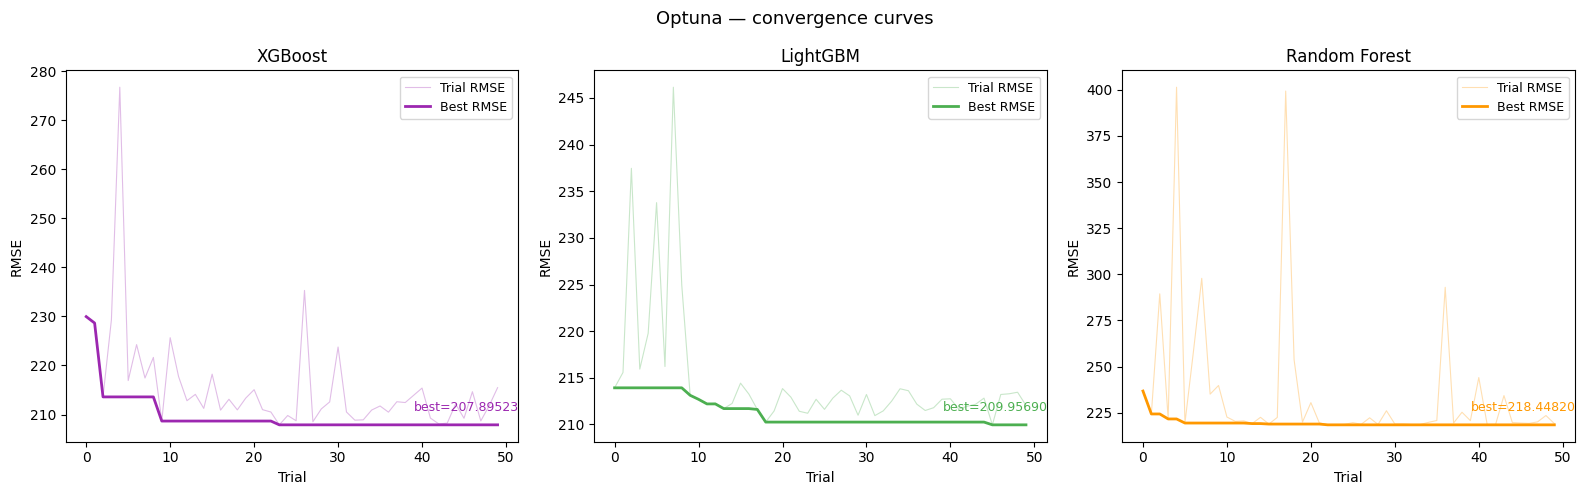

In [27]:
# Convergence curves — how the RMSE improved over the course of the trials

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, study, name, color in zip(
    axes,
    [xgbm_study, lgbm_study, rf_study],
    ['XGBoost', 'LightGBM', 'Random Forest'],
    ['#9C27B0', '#4CAF50', '#FF9800']
):
    values = [-t.value for t in study.trials if t.value is not None]
    best_so_far = pd.Series(values).cummin()

    ax.plot(values, alpha=0.3, color=color, linewidth=0.8, label='Trial RMSE')
    ax.plot(best_so_far, color=color, linewidth=2.0, label='Best RMSE')
    ax.set_title(f'{name}')
    ax.set_xlabel('Trial')
    ax.set_ylabel('RMSE')
    ax.legend(fontsize=9)
    ax.annotate(
        f'best={-study.best_value:.5f}',
        xy=(len(values)-1, best_so_far.iloc[-1]),
        xytext=(-60, 10), textcoords='offset points',
        fontsize=9, color=color
    )

plt.suptitle('Optuna — convergence curves', fontsize=13)
plt.tight_layout()
plt.show()

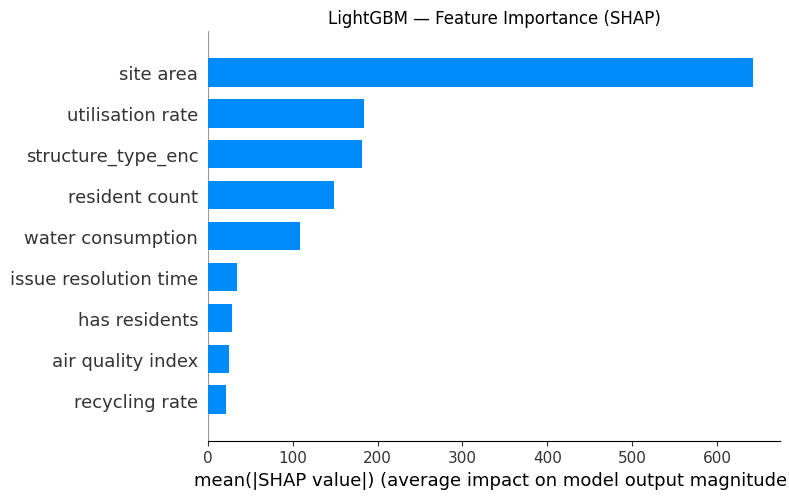

In [ ]:
# LightGBM explainer

lgbm_explainer = shap.TreeExplainer(final_lgbm)
lgbm_shap_values = lgbm_explainer.shap_values(X_boost_test)

plt.figure()
shap.summary_plot(lgbm_shap_values, X_boost_test, plot_type='bar', show=False)
plt.title('LightGBM — Feature Importance (SHAP)')
plt.tight_layout()
plt.show()

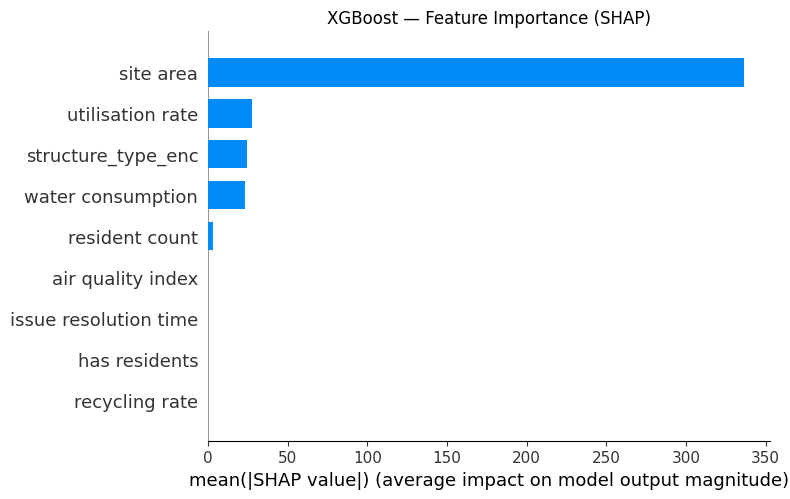

In [28]:
# XGBoost explainer

xgbm_explainer = shap.TreeExplainer(final_xgbm)
xgbm_shap_values = xgbm_explainer.shap_values(X_boost_test)

plt.figure()
shap.summary_plot(xgbm_shap_values, X_boost_test, plot_type='bar', show=False)
plt.title('XGBoost — Feature Importance (SHAP)')
plt.tight_layout()
plt.show()

In [ ]:
# Random Forest explainer

rf_explainer = shap.TreeExplainer(final_rf)
rf_shap_values = rf_explainer.shap_values(X_boost_test)

plt.figure()
shap.summary_plot(rf_shap_values, X_boost_test, plot_type='bar', show=False)
plt.title('Random Forest — Feature Importance (SHAP)')
plt.tight_layout()
plt.show()